In [1]:
import librosa
import math
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tf2onnx

from scipy import ndimage

from tensorflow import keras
from keras._tf_keras.keras.utils import to_categorical
from keras._tf_keras.keras.layers import (
    Dense, Reshape
)
from keras._tf_keras.keras.applications import MobileNetV2
from keras._tf_keras.keras.applications.mobilenet import preprocess_input
from sklearn.model_selection import train_test_split
from keras._tf_keras.keras.optimizers import Adam
from keras._tf_keras.keras.losses import CategoricalCrossentropy
from keras._tf_keras.keras.layers import Dropout
from keras._tf_keras.keras.callbacks import ModelCheckpoint

from keras._tf_keras.keras.constraints import non_neg
from keras._tf_keras.keras.regularizers import l2
from autopool.tf import AutoPool1D

from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

from keras._tf_keras.keras.models import load_model
from spec_augment import SpecAugment

2026-01-01 13:31:38.183795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-01 13:31:38.214003: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-01 13:31:38.214037: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-01 13:31:38.228882: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-01 13:31:39.496031: W tensorflow/compiler/tf

## Load GTZAN dataset

#### Implementation comments

From what I read one option to process the audio samples of each genre is to use spectrograms.

A spectogram is a visual representation of the spectrum of frequencies of a signal as it varies with time (time on the x axis and frequency on the y axis). It is generated by analyzing a signal in short time segments ofthen using the Short-Time Fourier Transform.

To be able to use the MobileNetV2 pre-trained model It is required to obtain a spectrogram of each audio sample. In order to achieve this one option is to use a Mel Spectrogram.

A Mel Spectrogram is a spectrogram where the frequency axis is transformed to the Mel scale, a perceptual scale that approximates the non-linear way the human ear perceives sound. It uses a logarithmic scale that reflects human auditory sensitivity, making it more aligned with how
humans perceive pitch and loudness. This is achieved by applying a bank of overlapping triangular filters, known as a Mel filterbank, to the power spectrum obtained from a Short-Time Fourier Transform.

In order to achieve this I came across a package called librosa which is a python package designed for audio and music analysis used to process and extract maningful information from audio signals.

#### Useful documentation

  * [mobilenet docs](https://keras.io/api/applications/mobilenet/)

  * [librosa docs](https://librosa.org/doc/latest/tutorial.html)

Some considerations for the mel spectrogram:
  * *Sample rate*: 16,000 Hz for balanced quality and computational efficiency, up to 22,050 for higher fidelity.
  * *Window size*: e.g. 25 ms corresponds to 400 samples at 16,000 Hz, standard values are 1024-2048.
  * *Window offset* (hop length): 8.33 ms are approximately 1/3 of the window size, standar values are 256-512 (16-32 ms).
  * *Number of mel filters*: Commonly between 40-80 for meaningful frequency bands, a power of 2 may be adequate.
  * *Frequency range*: minimum frequency is typically set to the lowest perceptually relevant frequency 0 or 0.1 Hz, for maximum frequency it is capped to 8,000 Hz to match human hearing limits.
  * *FFT length*: Should be chosen to balance frequency resolution and computational cost, a length of 2048 or 4096 is common, 2048 is sufficient for most applications, a power of 2 is recommended
  * *Normalization*: Helps stabilizing training in neural networks
  * *Logarithmic Scaling*: Converting the power spectrogram to decibels

In [2]:
#path to dataset
GTZAN_DS = "../data/gtzan_ds/"
#genres in alphanumeric order (same as in gtzan_ds folder)
GENRES = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]
#audio sample extension
WAV=".wav"

#path to store spectrogram np array values
GTZAN_NP_ARR="../data/gtzan_np_arr/"
#arr extension
NPY="npy"

In [3]:
#create folders to store spectrogram images
for genre in GENRES:
    os.makedirs(os.path.join(GTZAN_NP_ARR, genre), exist_ok=True)

In [4]:
def nearest_power_of_2(n):
    if n <= 0:
        raise ValueError("Number must be positive")
    k = math.floor(math.log2(n))
    lower_power = 2 ** k
    upper_power = 2 ** (k + 1)
    return lower_power if (n - lower_power) <= (upper_power - n) else upper_power

In [5]:

MS=1000 #to convert to miliseconds
OFF_SZ=3    #value for window offset size

DUR=30
SMPL_RT=16_000  # for sampling rate
WIN_TM=128   # value for window size later converted to miliseconds
WIN_SZ=nearest_power_of_2((WIN_TM/MS)*SMPL_RT)  #window size, recommended to use a power of 2
WIN_OFF=256
MEL_BANDS=64   #number of mel bands 40-80 up to 128
MIN_FRQ=0   #minimum frequency value
MAX_FRQ=8_000   #maximum frequency value
PWR=2   #power spectrogram value, 2 for power spectrogram

IMG_SZ=224    #for imagenetv2 image size

In [6]:
print(WIN_SZ, WIN_OFF)

2048 256


In [7]:
def resize_mel_spectrogram(spectrogram, height=IMG_SZ, width=IMG_SZ):
    #resize to desired size, or keep the same
    resized_spectrogram = ndimage.zoom(
        spectrogram,
        (
            height/spectrogram.shape[0],    #scale height to IMG_SZ
            width/spectrogram.shape[1],    #scale width to IMG_SZ
            1   #keep color channel unchanged
        ),
        order=1 #order 0 avoids interpolation, using 1 balances quality and speed
    )
    return resized_spectrogram

In [8]:
#function to create mel spectrogram from audio sample using librosa
def to_mel_spectrogram(
        source, 
        duration=DUR, 
        sample_rate=SMPL_RT,
        window_size=WIN_SZ,
        window_offset=WIN_OFF,
        mel_bands=MEL_BANDS,
        min_frq=MIN_FRQ,
        max_frq=MAX_FRQ,
        power=PWR
    ):
    #load audio sample
    audio_waveform, sampling_rate = librosa.load(
        source,
        duration=duration,
        sr=sample_rate
    )
    #create spectrogram from audio sample
    spectrogram = librosa.feature.melspectrogram(
        y=audio_waveform,
        sr=sampling_rate,
        n_fft=window_size,
        hop_length=window_offset,
        n_mels=mel_bands,
        fmin=min_frq,
        fmax=max_frq,
        power=power
    )
    #scale amplitude relative to max value in spectrogram
    #i.o.w highest power value in spectrogram is teated as 0 dB
    log_spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    #convert to rgb img, shape goes from (Height, Width) to (Height, Width, 3)
    rgb_log_spectrogram = np.stack([log_spectrogram] * 3, axis=-1)

    return rgb_log_spectrogram

In [9]:
#function to create spectrograms and save img and store spectrogram arrays
def generate_save_spectrograms(source_folder, classes, arr_folder, save_arr=False, load=False):
    spectrograms, genres = [], []
    if not load:
        #create spectrograms
        for idx, genre in enumerate(classes):
            genre_folder = os.path.join(source_folder, genre) # i.e. ../data/gtzan_ds/blues
            for audio in os.listdir(genre_folder)[:100]:   #each genre folder has 100 audio samples
                if audio.endswith(WAV):
                    audio_sample = os.path.join(genre_folder, audio)
                    try:
                        if save_arr:
                            #save spectrogram arr to respective np arr genre folder
                            arr_name = audio[:-3]
                            arr_name = arr_name+NPY
                            save_arr_to = os.path.join(arr_folder, genre, arr_name)
                            
                            spectrogram_arr = to_mel_spectrogram(audio_sample)
                            np.save(save_arr_to, spectrogram_arr)

                        #store spectrogram array to feature matrix
                        spectrograms.append(spectrogram_arr)
                        genres.append(idx)
                    except Exception as e:
                        print(f"Error processing audio sample: {audio} \n error: {e}")
                        continue
    else:
        #load spectrogram arrays
        for idx, genre in enumerate(classes):
            genre_folder = os.path.join(arr_folder, genre) # i.e. ../data/gtzan_np_arr/blues
            for arr in os.listdir(genre_folder)[:100]:   #each genre folder has 100 arrays except jazz 99
                if arr.endswith(NPY):
                    spectrogram = os.path.join(genre_folder, arr)
                    try:
                        spectrogram_arr = np.load(spectrogram)
                        #store spectrogram array to feature matrix
                        spectrograms.append(spectrogram_arr)
                        genres.append(idx)
                    except Exception as e:
                        print(f"Error processing spectrogram array: {arr} \n error: {e}")
                        continue
    
    return spectrograms, genres

The audio sample jazz.00054.wav fails to be processed

#### mel spectrogram shape

There is a catch here, the mel spectrogram has a rectangular shape, the problem is that each spectrogram element does not have consistency on shape, i found out trying to load each spectrogram using numpy

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (999, 64) + inhomogeneous part

So, indicating the expected shape is valid and the expected shape considering the mel spectrogram parameters is: (64, 1876, 3) or (mel bands, ((sample_rate/offset)*duration)+1, channels)

In [10]:
#create and save spectrogram data as np arr
#X, y = generate_save_spectrograms(GTZAN_DS, GENRES, GTZAN_NP_ARR, save_arr=True, load=False)

#load spectrogram arrays only
X, y = generate_save_spectrograms(GTZAN_DS, GENRES, GTZAN_NP_ARR, save_arr=False, load=True)

max_len = max(spectrogram.shape[1] for spectrogram in X)
X_load = np.zeros((len(X), 64, max_len, 3))

for idx, spectrogram in enumerate(X):
    X_load[idx, :, :spectrogram.shape[1], :] = spectrogram

#X_load = np.array(X)
y_load = np.array(y)
y_load = to_categorical(y, num_classes=len(GENRES))

In [11]:
X_load.shape

(999, 64, 1876, 3)

#### Basic EDA

As filenames are different but content may be the same a simple approach would be to reshape each spectrogram to 1D and using np.unique find unique rows (spectrograms)

Then using the unique indexes keep unique spectrograms in a separate array and using previous allocation to a zero filled numpy array initialized to expected spectrogram shape, populate with the obtained unique spectrogram data

In [12]:
X_load_reshaped = np.array([arr.flatten() for arr in X_load])
#ignore unique elements use unique index instead
_, unique_idxs = np.unique(X_load_reshaped, axis=0, return_index=True)

X_unique = [X[idx] for idx in sorted(unique_idxs)]
#X_load_unique = [X_load[idx] for idx in sorted(unique_idxs)]

In [13]:
#populate with unique spectrogram data
max_len = max(spectrogram.shape[1] for spectrogram in X_unique)
X_load = np.zeros((len(X_unique), 64, max_len, 3))

for idx, spectrogram in enumerate(X_unique):
    X_load[idx, :, :spectrogram.shape[1], :] = spectrogram

In [14]:
X_load.shape

(985, 64, 1876, 3)

In [15]:
Y_unique = np.array([y_load[idx] for idx in sorted(unique_idxs)])
Y_unique.shape

(985, 10)

To further remove duplicates I can use librosa to extract Mel-Frequency Cepstral Coefficients (MFCCs) which represent the spectral characteristics of sound in a way that aligns with human auditory perception

The number of MFCC coefficients (n_mfcc=13) is set to 13 because it effectively captures the spectral envelope of human speech and music, few coefficients (1–13) represent broad spectral shape and loudness, while higher coefficients capture fine details and noise. Using 13 coefficients balances feature richness with computational efficiency, avoiding redundancy and overfitting

Each mfcc sequence must have shape (time, n_mfcc)

In [16]:
X_mfccs = np.array([librosa.feature.mfcc(S=arr, n_mfcc=13) for arr in X_load])

In [17]:
X_mfccs.shape

(985, 64, 13, 3)

In [18]:
len(X_mfccs)

985

In [19]:
X_dtw = [X_mfccs[mfcc, 0, ...].T for mfcc in range(len(X_mfccs))]

In [20]:
len(X_dtw)

985

In [21]:
X_dtw[0].shape

(3, 13)

Dynamic Time Warping (DTW) is an algorithm used to measure the similarity between two temporal sequences that may vary in speed or timing such as time or series data

It works by finding an optimal alignment between the sequences though a non-linear warping of the time axis, allowing for variations in timing while preserving the overall shape of data

To apply it I have to compute pairwise DTW distances between all MFCCs and identify a threshold based on their distances where a low distance indicates a possible duplicate

In [22]:
#how many mfccs
n_mfccs = len(X_dtw)
distances = []

for mfcc_idx in range(n_mfccs):
    for next_mfcc in range(mfcc_idx+1, n_mfccs):
        distance, _ = fastdtw(X_dtw[mfcc_idx], X_dtw[next_mfcc], dist=euclidean)
        distances.append((mfcc_idx, next_mfcc, distance))

Visualize distances in order to identify a threshold

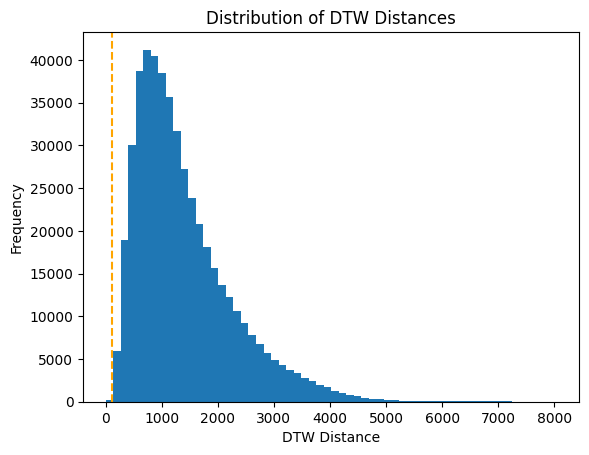

In [23]:
dists = [distance for _, _, distance in distances]
plt.hist(dists, bins=60)
plt.title("Distribution of DTW Distances")
plt.xlabel("DTW Distance")
plt.ylabel("Frequency")
plt.axvline(120, 0, color="orange", linestyle='--')
plt.show()

In [24]:
duplicate_pairs = [(i, j) for i, j, d in distances if d < 120]
len(duplicate_pairs)

138

In [25]:
to_remove = set()

for i, j in duplicate_pairs:
    to_remove.add(j)

unique_idxs = [idx for idx in range(len(X_dtw)) if idx not in to_remove]
len(unique_idxs)

906

In [26]:
X_unique = [X_load[idx] for idx in sorted(unique_idxs)]

In [27]:
max_len = max(spectrogram.shape[1] for spectrogram in X_unique)
X_load = np.zeros((len(X_unique), 64, max_len, 3))

for idx, spectrogram in enumerate(X_unique):
    X_load[idx, :, :spectrogram.shape[1], :] = spectrogram

In [28]:
X_load.shape

(906, 64, 1876, 3)

In [29]:
Y_load = np.array([y_load[idx] for idx in sorted(unique_idxs)])
Y_load.shape

(906, 10)

In [30]:
#create splits using 70,15,15 as train,validation,test respectively, dataset is small

#split to 70% train and 30% test
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_load, Y_load, test_size=0.3, stratify=Y_load, random_state=42
)

#split the 30% test to 15% train and 15% validation
X_test, X_vldtn, y_test, y_vldtn = train_test_split(
    X_val_test, y_val_test, test_size=0.5,
    stratify=y_val_test, random_state=42
)

print(len(X_train))
print(len(X_vldtn))
print(len(X_test))

634
136
136


I used stratify just to ensure class distribution is preserved in each set

In [ ]:
IN_SHAPE=X_load[0].shape
IN_SHAPE

#### Model Tuning

My first model approaches were not doing good and I forgot to apply eda as I was trying to find a way to process data to decide wether or not to keep going with this project.

Here the goal is to apply Data Augmentation on mel spectrogram data and see if model performance can be improved or not this time considering basic eda.

An option for augmentation is to apply time and frequency masking:

  * Frequency: In this case a frequency band is randomly selected and its values are set to zero, then it is applied multiple times.
  * Time: In this case a time segment is randomly masked and its consecutive time steps are set to zero, also applied multiple times.

Those options apply changes directly to the mel spectrogram similarly to the operations applied to images like resizing, rotating and so on.

#### Augmenting train data

In [ ]:
X_train.shape

#### Time Masking

Maximun width for the time mask would be 100 (Do not remove too much temporal information)

Hopefully a value in range 1-100 would help improve model performance

A tensor has shape (batch, time, frequency, channels)

One approach is to use tensorflow_io but reshaping tensor to (batch, time, freq)

Then apply time masking independently to each channel

In [ ]:
#preprocess training input for MobileNetV2
X_train_tm_pre = preprocess_input(X_train)

#preprocess validation input for MobileNetV2
X_vldtn_pre = preprocess_input(X_vldtn)

In [ ]:
X_train_tm_pre.shape

In [ ]:
type(X_train_tm_pre)

Using tensorflow yield the same error trying different approaches

I had to switch to spec augment to apply time mask

In [ ]:
X = tf.constant(X_train_tm_pre, dtype=tf.float32)
type(X)

In [ ]:
def get_time_mask(mask_value):
    spec_aug = SpecAugment(
        time_mask_param=mask_value,
        n_time_mask=1,
        mask_value=0,
        freq_mask_param=0,
        n_freq_mask=0
    )

    return spec_aug

In [ ]:
#time_mask = get_time_mask(0)
#X_masked = time_mask(X)
#X_masked.shape

Now apply time mask when training a model

In [ ]:
REG=0.01
METRIC="accuracy"
ACTIVATE="relu"
EPOCHS=50
BATCH=32
LEARN_RT=0.01
INN_SZ=100
DROP=0.0

In [ ]:
def make_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=IN_SHAPE
    )
    
    base_model.trainable = False

    inputs = keras.Input(shape=IN_SHAPE)
    base = base_model(inputs, training=False)

    #reshape input
    height, width, channels = base.shape[1], base.shape[2], base.shape[3]
    base_reshaped = Reshape((height * width, channels))(base)
    #shape (batch, time, features) so axis=1 to apply it to time
    vectors = AutoPool1D(
        axis=1, 
        kernel_constraint=non_neg(), 
        kernel_regularizer=l2(REG)
    )(base_reshaped)

    inner_layer = Dense(INN_SZ, activation=ACTIVATE)(vectors)
    drop = Dropout(rate=DROP)(inner_layer)

    outputs = Dense(len(GENRES))(drop)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=LEARN_RT)
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[METRIC]
    )

    return model

In [ ]:
mask_values = np.linspace(0, 100, 5)
print(mask_values)

In [ ]:
class CustomCallback(keras.callbacks.Callback):
    def __init__(self, tm_win):
        self.time_window = int(tm_win)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs["tm_win"] = self.time_window

In [ ]:
checkpoint = ModelCheckpoint(
    "../models/v6_tw_{tm_win}_{epoch:02d}_val_acc_{val_accuracy:.3f}.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [ ]:
#try time masks
mask_values = np.linspace(0, 100, 5)
scores = {}

#train a model for each time mask, save scores
for mask_value in mask_values:
    print(f"Time mask: {mask_value}")

    time_mask = get_time_mask(mask_value)
    X_masked = time_mask(X)

    model_aug_tm = make_model()
    history = model_aug_tm.fit(
        X_masked,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_data=(X_vldtn_pre, y_vldtn),
        callbacks=[CustomCallback(mask_value), checkpoint]
    )

    scores[str(mask_value)] = history.history
    print("====")

In [ ]:
TRN_ACC = "Training accuracy"
VAL_ACC = "Validation accuracy"
ACC = "accuracy"
ACC_VAL = "val_accuracy"

In [ ]:
for tm, history in scores.items():
    plt.plot(history[ACC], label=tm)

plt.title(TRN_ACC)
plt.legend()
plt.show()

In [ ]:
for tm, history in scores.items():
    plt.plot(history[ACC_VAL], label=tm)

plt.title(VAL_ACC)
plt.legend()
plt.show()

Surprisingly applying a time window of 25 achieved a better result than not applying it

In [ ]:
mask_values = np.linspace(0, 50, 6)
mask_values

In [ ]:
#try time masks
mask_values = np.linspace(0, 50, 6)
scores = {}

#train a model for each time mask, save scores
for mask_value in mask_values:
    print(f"Time mask: {mask_value}")

    time_mask = get_time_mask(mask_value)
    X_masked = time_mask(X)

    model_aug_tm = make_model()
    history = model_aug_tm.fit(
        X_masked,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_data=(X_vldtn_pre, y_vldtn),
        callbacks=[CustomCallback(mask_value), checkpoint]
    )

    scores[str(mask_value)] = history.history
    print("====")

In [ ]:
for tm, history in scores.items():
    plt.plot(history[ACC], label=tm)

plt.title(TRN_ACC)
plt.legend()
plt.show()

In [ ]:
for tm, history in scores.items():
    plt.plot(history[ACC_VAL], label=tm)

plt.title(VAL_ACC)
plt.legend()
plt.show()

In [ ]:
mask_values = np.linspace(21, 31, 6)
mask_values

In [ ]:
#try time masks
mask_values = np.linspace(21, 31, 6)
scores = {}

#train a model for each time mask, save scores
for mask_value in mask_values:
    print(f"Time mask: {mask_value}")

    time_mask = get_time_mask(mask_value)
    X_masked = time_mask(X)

    model_aug_tm = make_model()
    history = model_aug_tm.fit(
        X_masked,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_data=(X_vldtn_pre, y_vldtn)
    )

    scores[str(mask_value)] = history.history
    print("====")

In [ ]:
for tm, history in scores.items():
    plt.plot(history[ACC], label=tm)

plt.title(TRN_ACC)
plt.legend()
plt.show()

In [ ]:
for tm, history in scores.items():
    plt.plot(history[ACC_VAL], label=tm)

plt.title(VAL_ACC)
plt.show()

Best model was achieved using a time mask of 25

#### Frequency mask

Note: After trying out frequency masking it not performed well so I commented all cells

In [ ]:
#preprocess augmented training input for MobileNetV2
#X_train_tm_pre = preprocess_input(X_train)

#preprocess validation input for MobileNetV2
#X_vldtn_pre = preprocess_input(X_vldtn)

In [ ]:
#X = tf.constant(X_train_tm_pre, dtype=tf.float32)
#type(X)

In [ ]:
#checkpoint = ModelCheckpoint(
#    "../models/v6_aug_frq_{epoch:02d}_val_acc_{val_accuracy:.3f}.keras",
#    save_best_only=True,
#    monitor="val_accuracy",
#    mode="max"
#)

In [ ]:
#mel bands are up to 64, consider this for n_bins
#def get_frequency_mask(n_bins):
#    spec_aug = SpecAugment(
#        freq_mask_param=n_bins,
#        n_freq_mask=1,
#        time_mask_param=0,
#        n_time_mask=0
#    )
#
#    return spec_aug

In [ ]:
#mask_values = np.linspace(1, 64, 8)
#print(mask_values)

In [ ]:
#try frquency masks
#bin_values = np.linspace(1, 64, 8)

#scores = {}
#train a model for each frequency mask, save scores
#for bin_value in bin_values:
#    print(f"Frequency mask: {bin_value}")
#
#    freq_mask = get_frequency_mask(bin_value)
#    
#    X_masked = freq_mask(X)
#
#    model_aug_frq = make_model()
#
#    history = model_aug_frq.fit(
#        X_masked,
#        y_train,
#        epochs=EPOCHS,
#        batch_size=BATCH,
#        validation_data=(X_vldtn_pre, y_vldtn),
#        #callbacks=[checkpoint]
#    )
#
#    scores[str(bin_value)] = history.history
#
#    print("====")

In [ ]:
#for fm, history in scores.items():
#    plt.plot(history["accuracy"], label=fm)
#
#plt.title("Training accuracy")
#plt.legend()
#plt.show()

In [ ]:
#for fm, history in scores.items():
#    plt.plot(history["val_accuracy"], label=fm)
#
#plt.title("Validation accuracy")
#plt.legend()
#plt.show()

#### Export final model

In [2]:
#had to specify AutoPool1D explicitly
model_v6 = load_model(
    "../models/v6_tw_25_35_val_acc_0.706.keras",
    custom_objects={"AutoPool1D": AutoPool1D}
)

2025-12-31 00:23:07.284080: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-31 00:23:07.924587: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-31 00:23:07.927709: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [ ]:
#I had to add explicit input definition for conversion
spec = tf.TensorSpec(model_v6.input_shape, model_v6.input.dtype, name="input")

In [5]:
#convert to onnx
model_v6_onnx, _ = tf2onnx.convert.from_keras(model_v6, input_signature=[spec], opset=13)

2025-12-31 00:33:08.352205: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-31 00:33:08.357058: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2025-12-31 00:33:08.357131: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2025-12-31 00:33:08.357470: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-31 00:33:08.360326: I external/local_xla/xla/stream_executor/cuda/cuda_e

In [6]:
#save
ONNX_MODEL = "model_v6_onnx.onnx"
with open("../models/"+ONNX_MODEL, "wb") as f_out:
    f_out.write(model_v6_onnx.SerializeToString())

#### Save test data to use after deployment

Here i just picked a spectrogram of each genre to test

In [45]:
test_indices = [5, 12, 3, 10, 17, 4, 1, 23, 0, 13]
y_test[test_indices]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [48]:
test_spectrograms = X_test[test_indices]

In [49]:
GTZAN_TEST_ONLY = "../data/gtzan_test_data/"
for genre in GENRES:
    os.makedirs(os.path.join(GTZAN_TEST_ONLY, genre), exist_ok=True)

In [50]:
TEST = "test"
for idx in range(len(GENRES)):
    arr_name = GENRES[idx]+"_"+TEST
    arr_name = arr_name+NPY
    save_arr_to = os.path.join(os.path.join(GTZAN_TEST_ONLY, GENRES[idx]), arr_name)
    np.save(save_arr_to, test_spectrograms[idx])